In [ ]:
!pip install dowhy==0.14 econml==0.16.0 lightgbm networkx matplotlib pysensemakr sdv pingouin scipy --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.1/530.1 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.9/206.9 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.5/245.5 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import dowhy
import econml
import lightgbm
import networkx
import matplotlib
import sklearn
import pandas
import numpy
import scipy

print("dowhy     :", dowhy.__version__)
print("econml    :", econml.__version__)
print("lightgbm  :", lightgbm.__version__)
print("numpy     :", numpy.__version__)
print("pandas    :", pandas.__version__)
print("ALL PACKAGES LOADED SUCCESSFULLY")

dowhy     : 0.14
econml    : 0.16.0
lightgbm  : 4.6.0
numpy     : 2.0.2
pandas    : 2.2.2
ALL PACKAGES LOADED SUCCESSFULLY


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import dowhy
from dowhy import CausalModel

print(f"DoWhy version: {dowhy.__version__}")

DoWhy version: 0.14


In [ ]:
# ── STEP 1: DEFINE NODES AND EDGES ──────────────────────

NODES = {
    "multimedia_ratio":             "treatment",
    "performance_gain":             "outcome",
    "prior_achievement":            "confounder",
    "content_modality_preference":  "confounder",
    "bandwidth_category":           "confounder",
    "consistency":                  "confounder",
    "early_struggle":               "confounder",
    "skill_coverage":               "confounder",
    "session_duration_avg":         "confounder",
    "peer_activity_index":          "confounder",
    "school_resource_level":        "confounder",
    "tablet_access":                "confounder",
    "location_encoded":             "confounder",
    "teacher_qual":                 "outcome_only",
}

EDGES = [
    # Confounders → Treatment
    ("prior_achievement",           "multimedia_ratio"),
    ("content_modality_preference", "multimedia_ratio"),
    ("bandwidth_category",          "multimedia_ratio"),
    ("consistency",                 "multimedia_ratio"),
    ("early_struggle",              "multimedia_ratio"),
    ("skill_coverage",              "multimedia_ratio"),
    ("session_duration_avg",        "multimedia_ratio"),
    ("peer_activity_index",         "multimedia_ratio"),
    ("school_resource_level",       "multimedia_ratio"),
    ("tablet_access",               "multimedia_ratio"),
    ("location_encoded",            "multimedia_ratio"),

    # Confounders → Outcome
    ("prior_achievement",           "performance_gain"),
    ("content_modality_preference", "performance_gain"),
    ("bandwidth_category",          "performance_gain"),
    ("consistency",                 "performance_gain"),
    ("early_struggle",              "performance_gain"),
    ("skill_coverage",              "performance_gain"),
    ("session_duration_avg",        "performance_gain"),
    ("peer_activity_index",         "performance_gain"),
    ("school_resource_level",       "performance_gain"),
    ("tablet_access",               "performance_gain"),
    ("location_encoded",            "performance_gain"),

    # teacher_qual → Outcome ONLY
    ("teacher_qual",                "performance_gain"),

    # Main causal path T → Y
    ("multimedia_ratio",            "performance_gain"),
]

print("=" * 50)
print(f"Total nodes : {len(NODES)}")
print(f"Total edges : {len(EDGES)}")
print(f"Treatment   : multimedia_ratio")
print(f"Outcome     : performance_gain")
print("STEP 1 COMPLETE")

Total nodes : 14
Total edges : 24
Treatment   : multimedia_ratio
Outcome     : performance_gain
STEP 1 COMPLETE


In [ ]:
# ── STEP 2: BUILD DAG IN DoWhy ───────────────────────────

def build_gml_string(edges):
    lines = ["graph [", "  directed 1"]
    all_nodes = set()
    for src, tgt in edges:
        all_nodes.add(src)
        all_nodes.add(tgt)
    node_ids = {name: i for i, name in enumerate(sorted(all_nodes))}
    for name, idx in node_ids.items():
        lines.append(f'  node [ id {idx} label "{name}" ]')
    for src, tgt in edges:
        lines.append(f'  edge [ source {node_ids[src]} target {node_ids[tgt]} ]')
    lines.append("]")
    return "\n".join(lines)

gml_graph = build_gml_string(EDGES)

# Minimal synthetic dataset (required by DoWhy API)
np.random.seed(42)
n = 100
synthetic_df = pd.DataFrame({
    "multimedia_ratio":             np.random.uniform(0, 1, n),
    "performance_gain":             np.random.uniform(-0.3, 0.3, n),
    "prior_achievement":            np.random.uniform(0, 1, n),
    "content_modality_preference":  np.random.uniform(0, 1, n),
    "bandwidth_category":           np.random.choice([1, 2, 3], n),
    "consistency":                  np.random.uniform(0, 1, n),
    "early_struggle":               np.random.uniform(0, 1, n),
    "skill_coverage":               np.random.uniform(0, 1, n),
    "session_duration_avg":         np.random.uniform(5, 60, n),
    "peer_activity_index":          np.random.uniform(0, 5, n),
    "school_resource_level":        np.random.choice([1, 2, 3], n),
    "tablet_access":                np.random.choice([0, 1], n),
    "location_encoded":             np.random.choice([1, 2, 3], n),
    "teacher_qual":                 np.random.uniform(0, 1, n),
})

model = CausalModel(
    data=synthetic_df,
    treatment="multimedia_ratio",
    outcome="performance_gain",
    graph=gml_graph,
    proceed_when_unidentifiable=True,
)

print("STEP 2 COMPLETE — DoWhy CausalModel built")
print(model)

STEP 2 COMPLETE — DoWhy CausalModel built


In [ ]:
# ── STEP 3: IDENTIFY EFFECT ──────────────────────────────

identified_estimand = model.identify_effect(
    proceed_when_unidentifiable=True
)

print("=" * 50)
print("IDENTIFIED ESTIMAND:")
print(identified_estimand)

# Save to file for OSF pre-registration
with open("identified_estimand.txt", "w") as f:
    f.write(str(identified_estimand))

print("\n STEP 3 COMPLETE — Backdoor criterion verified")
print("identified_estimand.txt saved")

IDENTIFIED ESTIMAND:
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                      ↪
──────────────────(E[performance_gain|bandwidth_category,early_struggle,prior_ ↪
d[multimediaᵣₐₜᵢₒ]                                                             ↪

↪                                                                              ↪
↪ achievement,tablet_access,school_resource_level,session_duration_avg,consist ↪
↪                                                                              ↪

↪                                                                              ↪
↪ ency,skill_coverage,peer_activity_index,location_encoded,content_modality_pr ↪
↪                                                                              ↪

↪           
↪ eference])
↪           
Estimand assumption 1, Unconfoundedness: If U→{multimedia_ratio} and U→performance_gain then P(perf

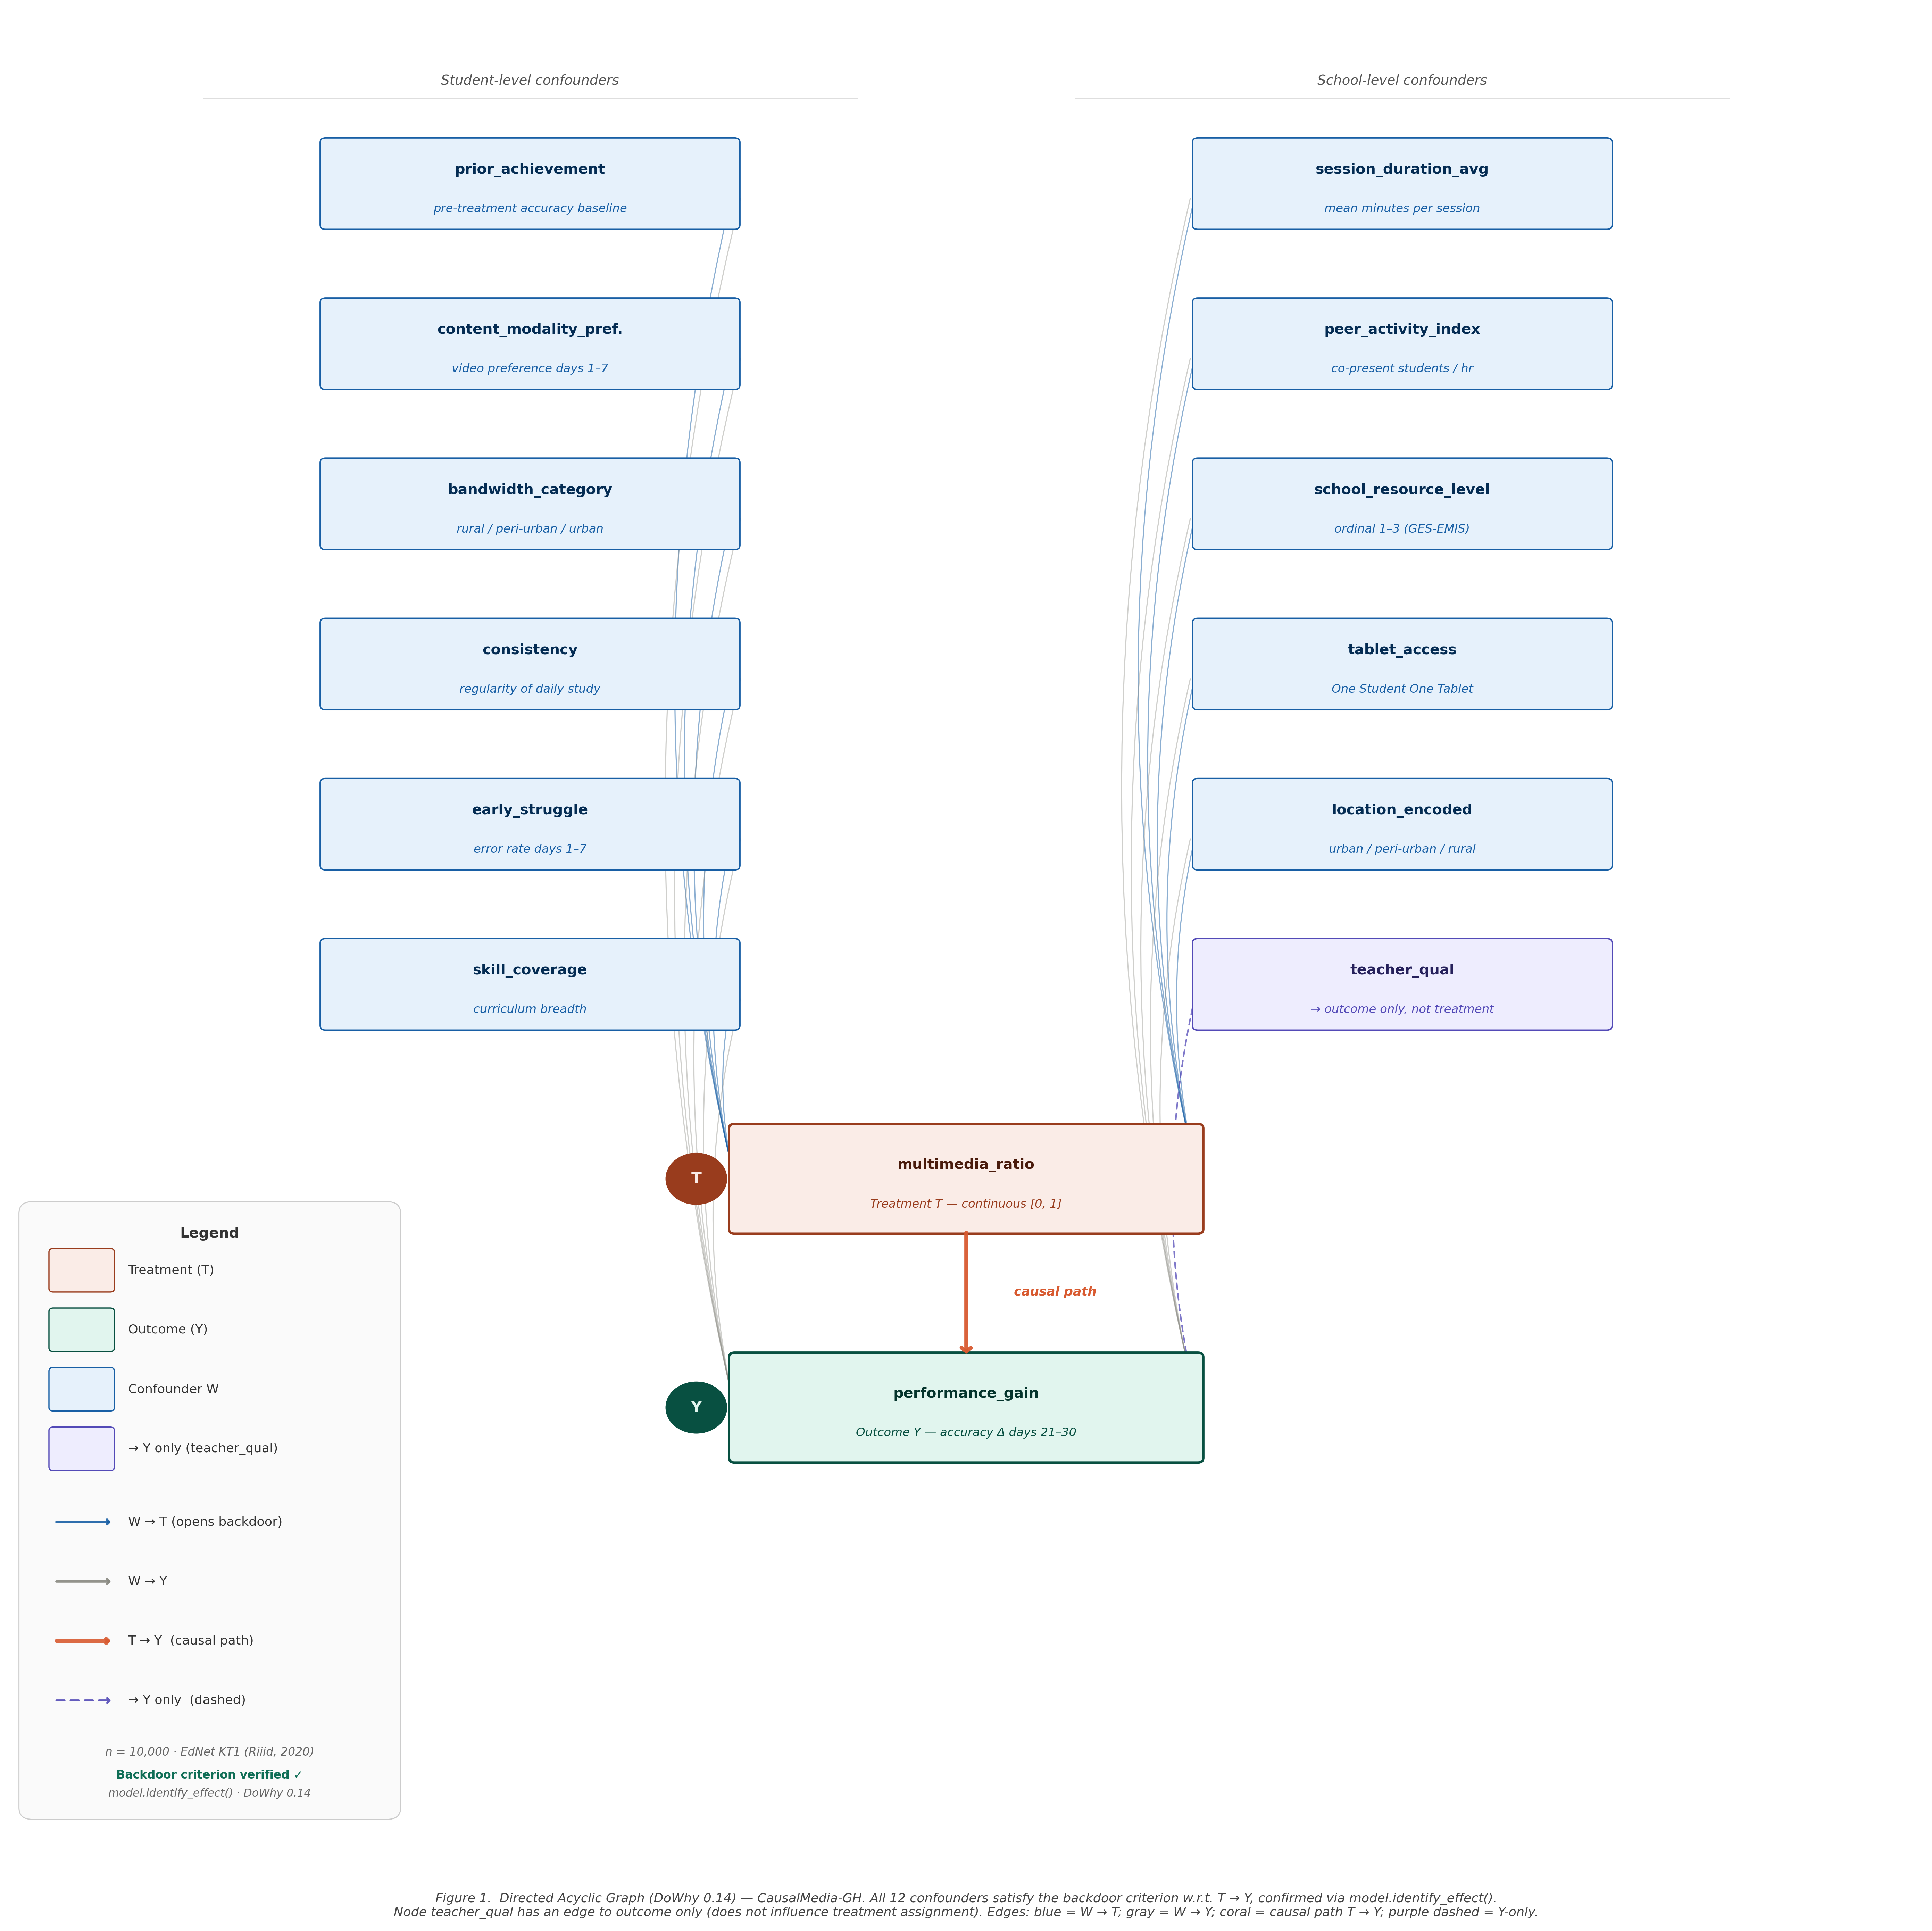

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe

# ── Font settings  ──────────────
plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "font.size":        10,
    "axes.linewidth":   0.7,
    "figure.dpi":       350,
})

fig, ax = plt.subplots(figsize=(16, 16))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.set_xlim(0, 14)
ax.set_ylim(0, 16)
ax.axis("off")

# ── Color palette ──────────────────────────────────────
C = {
    "treatment":   {"face": "#FAECE7", "edge": "#993C1D", "text": "#4A1B0C"},
    "outcome":     {"face": "#E1F5EE", "edge": "#085041", "text": "#04342C"},
    "confounder":  {"face": "#E6F1FB", "edge": "#185FA5", "text": "#042C53"},
    "out_only":    {"face": "#EEEDFE", "edge": "#534AB7", "text": "#26215C"},
    "edge_T":      "#185FA5",
    "edge_Y":      "#888880",
    "causal":      "#D85A30",
    "out_only_e":  "#534AB7",
    "border":      "#DDDDDD",
    "bg":          "#FAFAFA",
}

def draw_node(ax, x, y, w, h, label, sublabel, style, bold=False):
    box = FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.04",
        facecolor=style["face"],
        edgecolor=style["edge"],
        linewidth=0.8 if not bold else 1.4,
        zorder=3
    )
    ax.add_patch(box)
    ax.text(x, y + (0.12 if sublabel else 0), label,
            ha="center", va="center", fontsize=8.5,
            fontweight="600", color=style["text"], zorder=4)
    if sublabel:
        ax.text(x, y - 0.22, sublabel,
                ha="center", va="center", fontsize=7,
                color=style["edge"], style="italic", zorder=4)
    return (x, y)

def draw_arrow(ax, x1, y1, x2, y2, color, lw=0.7, alpha=0.6,
               dashed=False, label=None):
    ls = (0, (4, 3)) if dashed else "solid"
    ax.annotate("",
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->,head_width=0.18,head_length=0.18",
            color=color, lw=lw, alpha=alpha,
            linestyle=ls,
            connectionstyle="arc3,rad=0.12"
        ), zorder=2)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.1, my, label, fontsize=6.5,
                color=color, ha="left", va="center", zorder=5)

# ── Node positions ─────────────────────────────────────
# Student-level confounders (left column, top area)
conf_left = [
    (3.8, 14.5, "prior_achievement",           "pre-treatment accuracy baseline"),
    (3.8, 13.1, "content_modality_pref.",       "video preference days 1–7"),
    (3.8, 11.7, "bandwidth_category",           "rural / peri-urban / urban"),
    (3.8, 10.3, "consistency",                  "regularity of daily study"),
    (3.8,  8.9, "early_struggle",               "error rate days 1–7"),
    (3.8,  7.5, "skill_coverage",               "curriculum breadth"),
]

# School-level confounders (right column, lower area)
conf_right = [
    (10.2, 14.5, "session_duration_avg",        "mean minutes per session"),
    (10.2, 13.1, "peer_activity_index",         "co-present students / hr"),
    (10.2, 11.7, "school_resource_level",       "ordinal 1–3 (GES-EMIS)"),
    (10.2, 10.3, "tablet_access",               "One Student One Tablet"),
    (10.2,  8.9, "location_encoded",            "urban / peri-urban / rural"),
]

# Outcome-only
teacher = (10.2, 7.5, "teacher_qual",           "→ outcome only, not treatment")

# Treatment and outcome
T_pos = (7.0, 5.8)
Y_pos = (7.0, 3.8)

NW, NH = 3.0, 0.72  # node width, height
TW, TH = 3.4, 0.88  # treatment/outcome larger

# ── Draw section labels ────────────────────────────────
ax.text(3.8, 15.4, "Student-level confounders",
        ha="center", va="center", fontsize=8,
        color="#555", style="italic")
ax.plot([1.4, 6.2], [15.25, 15.25], color="#DDD", lw=0.6)

ax.text(10.2, 15.4, "School-level confounders",
        ha="center", va="center", fontsize=8,
        color="#555", style="italic")
ax.plot([7.8, 12.6], [15.25, 15.25], color="#DDD", lw=0.6)

# ── Draw edges FIRST (behind nodes) ───────────────────
# Confounder → T
for (x, y, *_) in conf_left:
    draw_arrow(ax, x+NW/2, y, T_pos[0]-TW/2, T_pos[1],
               C["edge_T"], lw=0.65, alpha=0.5)
for (x, y, *_) in conf_right[:5]:
    draw_arrow(ax, x-NW/2, y, T_pos[0]+TW/2, T_pos[1],
               C["edge_T"], lw=0.65, alpha=0.5)

# Confounder → Y
for (x, y, *_) in conf_left:
    draw_arrow(ax, x+NW/2+0.05, y-0.1, Y_pos[0]-TW/2, Y_pos[1],
               C["edge_Y"], lw=0.65, alpha=0.4)
for (x, y, *_) in conf_right[:5]:
    draw_arrow(ax, x-NW/2-0.05, y-0.1, Y_pos[0]+TW/2, Y_pos[1],
               C["edge_Y"], lw=0.65, alpha=0.4)

# teacher_qual → Y only (dashed purple)
draw_arrow(ax, teacher[0]-NW/2, teacher[1],
           Y_pos[0]+TW/2, Y_pos[1],
           C["out_only_e"], lw=0.9, alpha=0.75, dashed=True)

# Main causal path T → Y
ax.annotate("",
    xy=(Y_pos[0], Y_pos[1]+TH/2),
    xytext=(T_pos[0], T_pos[1]-TH/2),
    arrowprops=dict(
        arrowstyle="->,head_width=0.28,head_length=0.22",
        color=C["causal"], lw=2.2, alpha=0.95,
        connectionstyle="arc3,rad=0.0"
    ), zorder=5)

# Causal path label
ax.text(7.35, 4.81, "causal path", fontsize=7.5,
        color=C["causal"], fontweight="600",
        ha="left", va="center", style="italic", zorder=6)

# ── Draw nodes OVER edges ──────────────────────────────
for (x, y, label, sub) in conf_left:
    draw_node(ax, x, y, NW, NH, label, sub, C["confounder"])

for (x, y, label, sub) in conf_right:
    draw_node(ax, x, y, NW, NH, label, sub, C["confounder"])

draw_node(ax, teacher[0], teacher[1], NW, NH,
          teacher[2], teacher[3], C["out_only"])

draw_node(ax, T_pos[0], T_pos[1], TW, TH,
          "multimedia_ratio", "Treatment T — continuous [0, 1]",
          C["treatment"], bold=True)

draw_node(ax, Y_pos[0], Y_pos[1], TW, TH,
          "performance_gain", "Outcome Y — accuracy Δ days 21–30",
          C["outcome"], bold=True)

# T and Y badges
for (bx, by, col, fc, lbl) in [
    (T_pos[0]-TW/2-0.28, T_pos[1], C["treatment"]["edge"],
     C["treatment"]["face"], "T"),
    (Y_pos[0]-TW/2-0.28, Y_pos[1], C["outcome"]["edge"],
     C["outcome"]["face"], "Y"),
]:
    circ = plt.Circle((bx, by), 0.22, color=col, zorder=6)
    ax.add_patch(circ)
    ax.text(bx, by, lbl, ha="center", va="center",
            fontsize=9, fontweight="700", color=fc, zorder=7)

# ── Legend box ─────────────────────────────────────────
leg_box = FancyBboxPatch((0.15, 0.3), 2.6, 5.2,
    boxstyle="round,pad=0.1",
    facecolor="#FAFAFA", edgecolor="#CCCCCC", linewidth=0.6, zorder=3)
ax.add_patch(leg_box)
ax.text(1.45, 5.32, "Legend", ha="center", va="center",
        fontsize=8.5, fontweight="600", color="#333")

legend_items = [
    (C["treatment"]["face"], C["treatment"]["edge"], "Treatment (T)"),
    (C["outcome"]["face"],   C["outcome"]["edge"],   "Outcome (Y)"),
    (C["confounder"]["face"],C["confounder"]["edge"], "Confounder W"),
    (C["out_only"]["face"],  C["out_only"]["edge"],   "→ Y only (teacher_qual)"),
]
for i, (fc, ec, lbl) in enumerate(legend_items):
    yy = 5.0 - i * 0.52
    rect = FancyBboxPatch((0.3, yy-0.16), 0.42, 0.32,
        boxstyle="round,pad=0.03",
        facecolor=fc, edgecolor=ec, linewidth=0.7, zorder=4)
    ax.add_patch(rect)
    ax.text(0.85, yy, lbl, va="center", fontsize=7.5, color="#333", zorder=4)

edge_items = [
    (C["edge_T"],   "solid",    1.4, "W → T (opens backdoor)"),
    (C["edge_Y"],   "solid",    1.4, "W → Y"),
    (C["causal"],   "solid",    2.2, "T → Y  (causal path)"),
    (C["out_only_e"],(0,(4,3)), 1.2, "→ Y only  (dashed)"),
]
for i, (col, ls, lw, lbl) in enumerate(edge_items):
    yy = 2.8 - i * 0.52
    ax.annotate("",
        xy=(0.75, yy), xytext=(0.3, yy),
        arrowprops=dict(
            arrowstyle="->,head_width=0.14,head_length=0.14",
            color=col, lw=lw, linestyle=ls, alpha=0.9
        ), zorder=4)
    ax.text(0.85, yy, lbl, va="center", fontsize=7.5, color="#333", zorder=4)

# Divider + stats note
ax.plot([0.25, 2.7], [0.95, 0.95], color="#DDD", lw=0.6)
ax.text(1.45, 0.76, "n = 10,000 · EdNet KT1 (Riiid, 2020)",
        ha="center", fontsize=6.8, color="#666", style="italic")
ax.text(1.45, 0.56, "Backdoor criterion verified ✓",
        ha="center", fontsize=6.8, color="#0F6E56", fontweight="600")
ax.text(1.45, 0.40, "model.identify_effect() · DoWhy 0.14",
        ha="center", fontsize=6.5, color="#666", style="italic")

# ── Figure caption ─────────────────────────────────────
fig.text(
    0.5, 0.01,
    "Figure 1.  Directed Acyclic Graph (DoWhy 0.14) — CausalMedia-GH. "
    "All 12 confounders satisfy the backdoor criterion w.r.t. T → Y, "
    "confirmed via model.identify_effect().\n"
    "Node teacher_qual has an edge to outcome only (does not influence "
    "treatment assignment). Edges: blue = W → T; gray = W → Y; "
    "coral = causal path T → Y; purple dashed = Y-only.",
    ha="center", va="bottom", fontsize=7.5,
    color="#444", style="italic", wrap=True
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("figure1_dag_causalmedia_gh.png", dpi=300,
            bbox_inches="tight", facecolor="white")


In [ ]:
import os
from google.colab import files


if not os.path.exists("identified_estimand.txt"):
    identified_estimand = model.identify_effect(
        proceed_when_unidentifiable=True
    )
    with open("identified_estimand.txt", "w") as f:
        f.write(str(identified_estimand))
    print("identified_estimand.txt created")
else:
    print("identified_estimand.txt already exists")

# ── Save the figure ────────────────────────────────────────
fig.savefig("figure1_dag_causalmedia_gh.png", dpi=300,
            bbox_inches="tight", facecolor="white")
print("figure1_dag_causalmedia_gh.png saved")

# ── Download both ──────────────────────────────────────────
files.download("figure1_dag_causalmedia_gh.png")
files.download("identified_estimand.txt")
print("Downloads triggered")

✅ identified_estimand.txt already exists
✅ figure1_dag_causalmedia_gh.png saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloads triggered
